In [100]:
import numpy as np
import matplotlib.pyplot as plt
from Corrfunc.theory import xi

In [101]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [102]:
boxsize = 205

In [103]:
seed = 0

In [104]:
nhalos = 500000 # of order of number of halos in tng300

In [105]:
from sklearn.neighbors import KDTree

# R1 sample
seed1 = 0
rng1 = np.random.RandomState(seed1)
X1 = rng1.random_sample((nhalos, 3))*boxsize  # nhalos in 3 dimensions

# R2 sample
seed2 = 1
rng2 = np.random.RandomState(seed2)
X2 = rng2.random_sample((nhalos, 3))*boxsize  # nhalos in 3 dimensions

Find indices where the halos are less than r=distance of each other

In [124]:
R1 = 0.4
R2 = 0.2

`ind` returns an array of arrays. In each array is the index of the halo and any other halos that are within r = distance. If the array only has one element then it means there are no halos within `r = distance`.

Remove halos which are less than r=distance within each other

In [125]:
def remove_halos(X, R):
    distance = 2*R
    tree = KDTree(X, leaf_size=2)
    ind = tree.query_radius(X, r=distance)

    mask = np.array([True]*len(X))

    for i, indices in enumerate(ind):
        #print(indices)
        if (len(indices) > 1): # if true, then there exist halos within r = distance
            mask1 = indices > i # get all halos with index after i
            #if np.any(mask1): # if any of them are true
            if np.sum(mask1)>0: # if there exist any indices greater than i (which are within r of halo i) - the ones with lower indices have already been removed
                mask[i] = False # remove halo at index i
    X_exclusion = X[mask]
    return X_exclusion

In [126]:
X_excl1 = remove_halos(X1, R1)
nhalos_remaining1 = len(X_excl1)
print(nhalos_remaining1)

470211


In [127]:
X_excl2 = remove_halos(X2, R2)
nhalos_remaining2 = len(X_excl2)
print(nhalos_remaining2)

496218


If a small halo gets to close to a larger halo it is likely that it is classified as part of the large halo - therefore let's remove the small halo if this happens

In [128]:
def remove_halos2(X1, X2, R1, R2):
    distance = R1 + R2
    tree = KDTree(X2, leaf_size=2)
    ind = tree.query_radius(X1, r=distance) # Returns a list of arrays - each array shows X2 index if within dR of X1
    
    indices2remove = list(set(np.concatenate(ind)))
    
    mask = np.array([True]*len(X2))
        
    mask[indices2remove] = False
    
    
    X2_removed = X2[mask]

    
#     for i, indices in enumerate(ind):
#         #print(indices)
#         if (len(indices) > 1): # if true, then there exist halos within r = distance
#             mask1 = indices > i # get all halos with index after i
#             #if np.any(mask1): # if any of them are true
#             if np.sum(mask1)>0: # if there exist any indices greater than i (which are within r of halo i) - the ones with lower indices have already been removed
#                 mask[i] = False # remove halo at index i
#     X_exclusion = X[mask]

    return X2_removed

In [129]:
dR = R1 + R2
X1_removed = remove_halos2(X_excl2, X_excl1, R2, R1)

In [130]:
halos2_remaining = len(X_excl2)
print(halos2_remaining)

496218


In [131]:
halos1_remaining = len(X1_removed)
print(halos1_remaining)

446435


In [132]:
halos2_remaining+halos1_remaining

942653

In [133]:
X_all = np.concatenate((X_excl2, X1_removed))

In [134]:
len(X_all)

942653

Check correlation function of this random distribution with halo exclusion

In [135]:

rmin = 0.1
rmax = 10.0
nbins = 100
bins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1)
results2 = xi(boxsize, 2, bins , X_all[:,0],X_all[:,1],X_all[:,2], 
             weights=None,output_ravg=True)

In [136]:
bin_cents = (bins[:-1]+bins[1:])/2

In [137]:
ravg2 = np.where(results2["ravg"]==0, bin_cents, results2["ravg"])


(-1.1, 0.1)

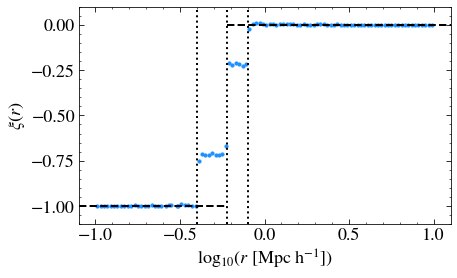

In [138]:
plt.hlines(-1, xmin=-1.1, xmax=np.log10(0.6), color="k", linestyle="dashed")
plt.hlines(0, xmin=np.log10(0.6), xmax=1.1, color="k", linestyle="dashed")

plt.vlines(np.log10(2*R1), ymin=-1.1, ymax=0.1, color="k", linestyle="dotted")
plt.vlines(np.log10(R1+R2), ymin=-1.1, ymax=0.1, color="k", linestyle="dotted")
plt.vlines(np.log10(2*R2), ymin=-1.1, ymax=0.1, color="k", linestyle="dotted")
plt.scatter(np.log10(ravg2), results2["xi"], s=10, color="DodgerBlue")
plt.xlabel("log$_{10}$($r$ [Mpc h$^{-1}$])")
plt.ylabel(r"$\xi$($r$)")
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 0.1)
#plt.savefig("../figures/correlation_function_2R=0.6.pdf", format="pdf", bbox_inches="tight")

In [140]:
x_cent, y_cent, z_cent = X_all[:,0], X_all[:,1], X_all[:,2]

In [141]:

with open(f"random_halo_exclusion_R1={R1}_R2={R2}.txt", "w") as f:
    print("# logM[Msun/h] x[Mpc/h] y[Mpc/h] z[Mpc/h] SFR[Msun/yr]", file=f)

    for i in range(len(x_cent)):
        print(1, x_cent[i],y_cent[i],z_cent[i], 1, file = f)